<a href="https://colab.research.google.com/github/kxrrym03/Duolingo-Forgetting-Curve/blob/main/Forgetting_Curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving forgetting_curve.csv to forgetting_curve.csv


In [ ]:
df = pd.read_csv('forgetting_curve.csv')
df.shape

(310, 10)

In [ ]:
df.head()

,learning_language,language_name,lag_bin,lag_bin_order,practice_bin,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions
0,all,All languages,<1 hour,0,1-2 exposures,0,383261,0.9157,0.9191,87.37
1,all,All languages,<1 hour,0,3-4 exposures,1,893452,0.9137,0.9177,86.26
2,all,All languages,<1 hour,0,5-9 exposures,2,1429269,0.9129,0.9186,86.50
3,all,All languages,<1 hour,0,10-19 exposures,3,1023779,0.9129,0.9199,86.00
4,all,All languages,<1 hour,0,20+ exposures,4,1239541,0.8995,0.9097,84.58


In [ ]:
df.tail()

,learning_language,language_name,lag_bin,lag_bin_order,practice_bin,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions
305,pt,Portuguese,3+ months,8,1-2 exposures,0,386,0.8765,0.8775,80.05
306,pt,Portuguese,3+ months,8,3-4 exposures,1,812,0.8670,0.8776,77.71
307,pt,Portuguese,3+ months,8,5-9 exposures,2,670,0.8805,0.8791,79.55
308,pt,Portuguese,3+ months,8,10-19 exposures,3,351,0.8649,0.8764,77.21
309,pt,Portuguese,3+ months,8,20+ exposures,4,63,0.8791,0.8923,79.37


In [ ]:
df.isnull().sum()

,0
learning_language,0
language_name,0
lag_bin,0
lag_bin_order,0
practice_bin,0
practice_bin_order,0
n_traces,0
avg_session_recall,0
item_recall_rate,0
pct_perfect_sessions,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,lag_bin_order,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions
count,310.000000,310.0000,3.100000e+02,310.000000,310.000000,310.000000
mean,3.935484,2.0000,8.293049e+04,0.888834,0.897956,83.082161
std,2.555981,1.4165,1.573597e+05,0.017793,0.014307,2.836484
min,0.000000,0.0000,6.300000e+01,0.818100,0.851800,72.610000
25%,2.000000,1.0000,1.186825e+04,0.878000,0.888025,81.532500
50%,4.000000,2.0000,3.324150e+04,0.889200,0.898500,83.260000
75%,6.000000,3.0000,8.646775e+04,0.900050,0.905850,84.677500
max,8.000000,4.0000,1.429269e+06,0.932900,0.933700,90.170000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   learning_language     310 non-null    object 
 1   language_name         310 non-null    object 
 2   lag_bin               310 non-null    object 
 3   lag_bin_order         310 non-null    int64  
 4   practice_bin          310 non-null    object 
 5   practice_bin_order    310 non-null    int64  
 6   n_traces              310 non-null    int64  
 7   avg_session_recall    310 non-null    float64
 8   item_recall_rate      310 non-null    float64
 9   pct_perfect_sessions  310 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 24.3+ KB


In [ ]:
df.dtypes

,0
learning_language,object
language_name,object
lag_bin,object
lag_bin_order,int64
practice_bin,object
practice_bin_order,int64
n_traces,int64
avg_session_recall,float64
item_recall_rate,float64
pct_perfect_sessions,float64


In [ ]:
df.columns

Index(['learning_language', 'language_name', 'lag_bin', 'lag_bin_order',
       'practice_bin', 'practice_bin_order', 'n_traces', 'avg_session_recall',
       'item_recall_rate', 'pct_perfect_sessions'],
      dtype='object')

## Data Analysis and Visualization

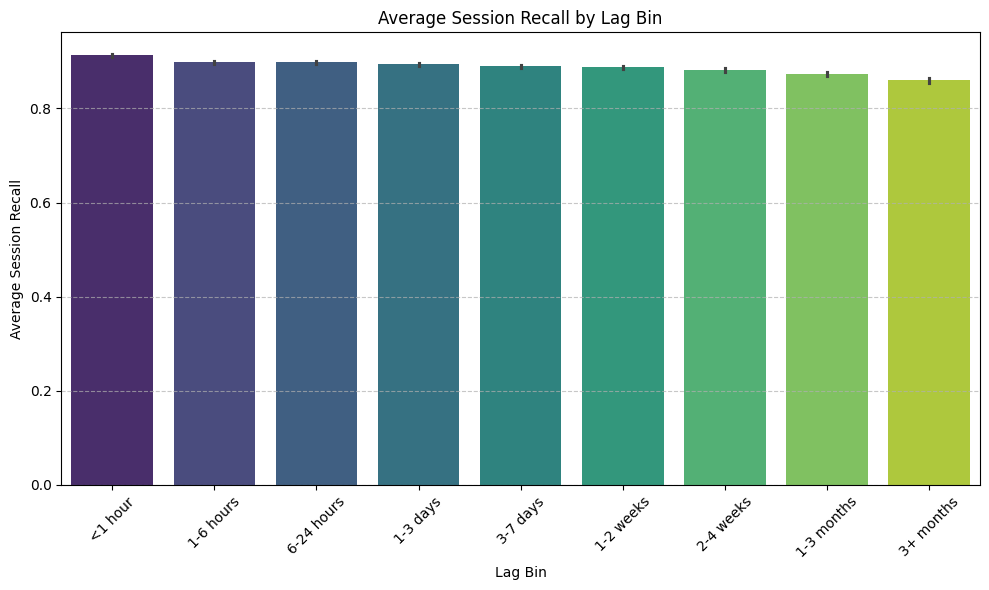

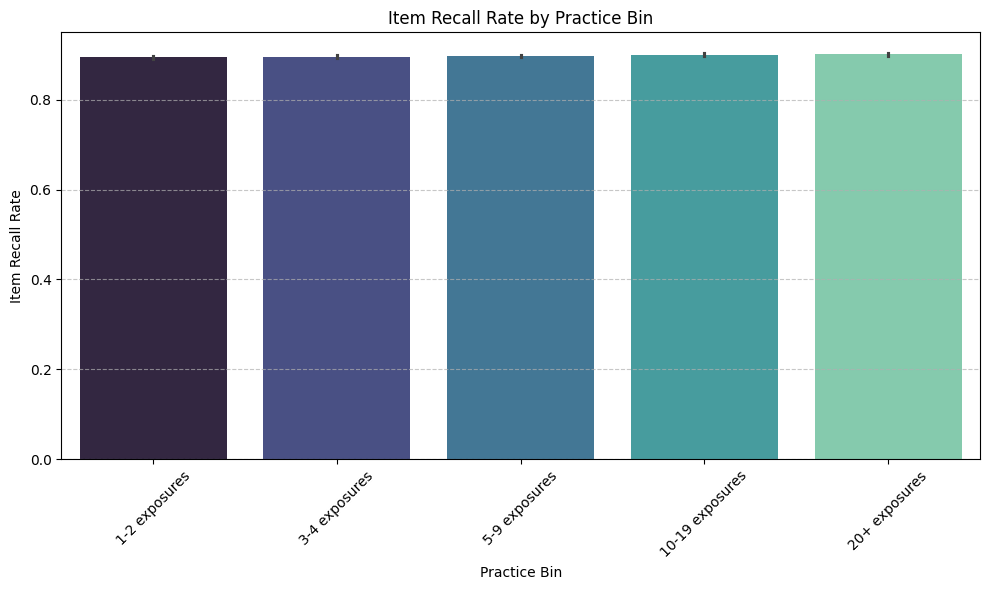

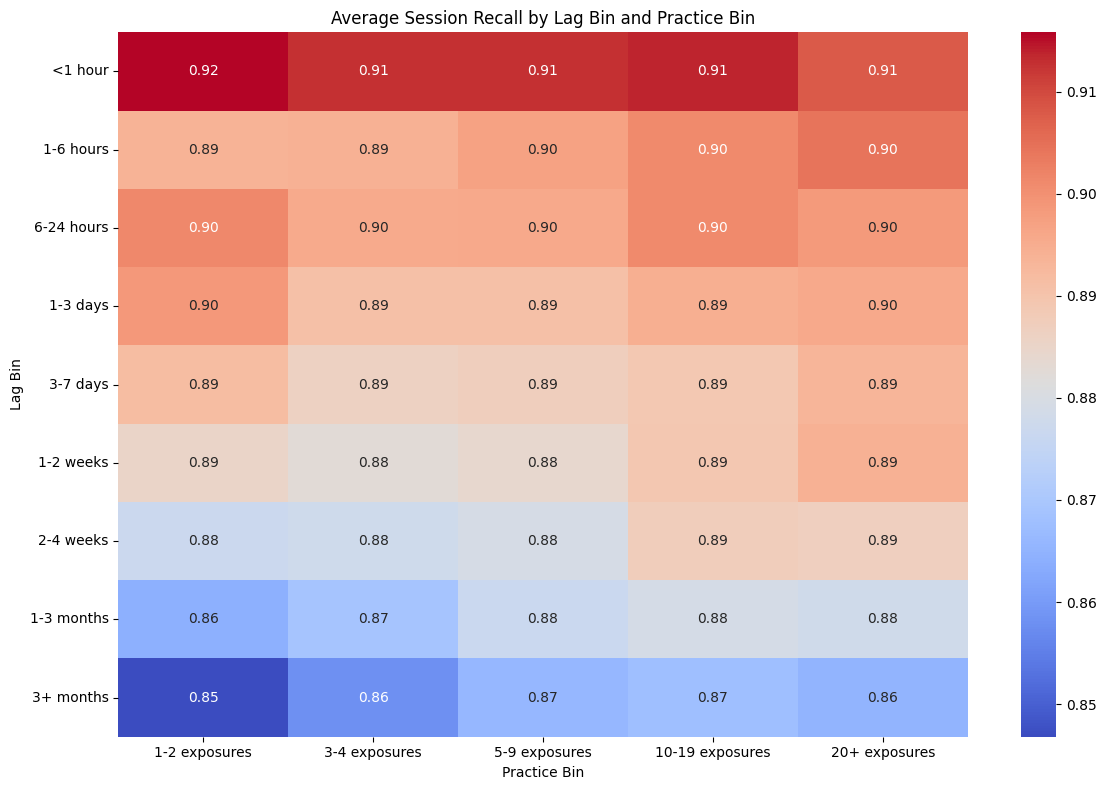

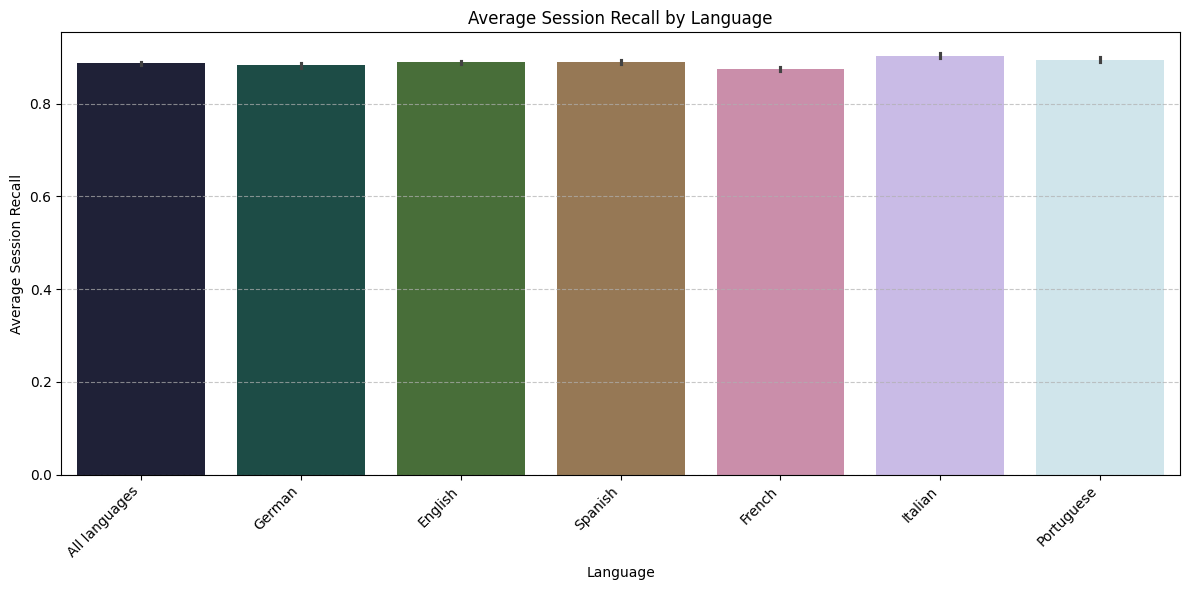

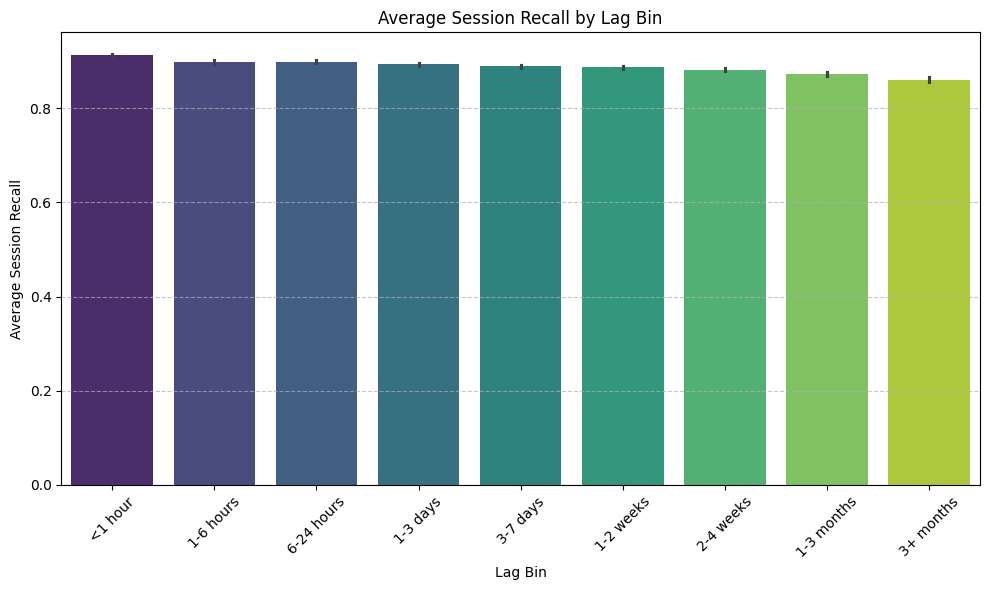

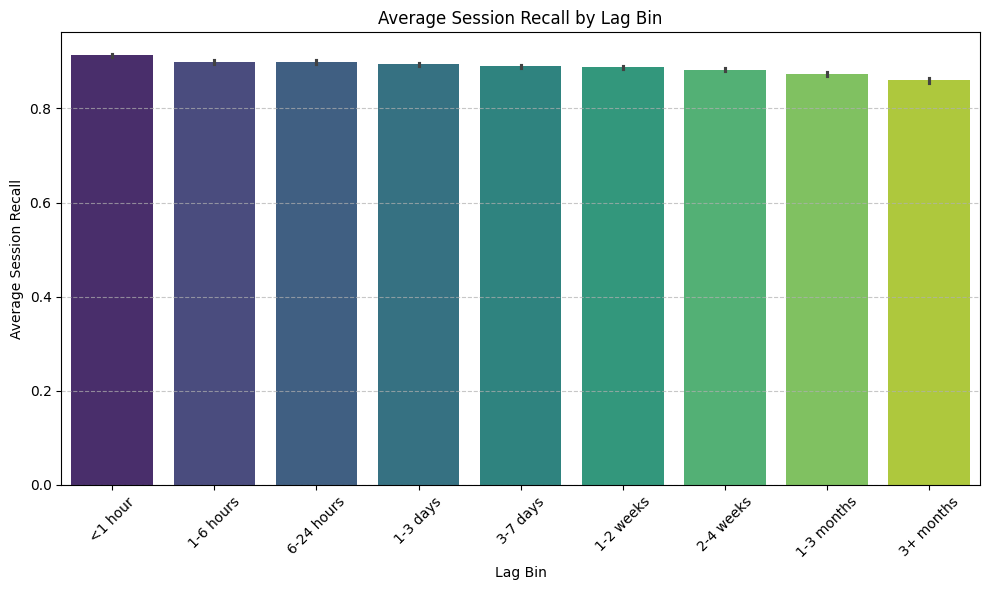

In [ ]:
# Average Session Recall by Lag Bin
plt.figure(figsize=(10, 6))
sns.barplot(x='lag_bin', y='avg_session_recall', data=df.sort_values('lag_bin_order'), palette='viridis')
plt.title('Average Session Recall by Lag Bin')
plt.xlabel('Lag Bin')
plt.ylabel('Average Session Recall')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

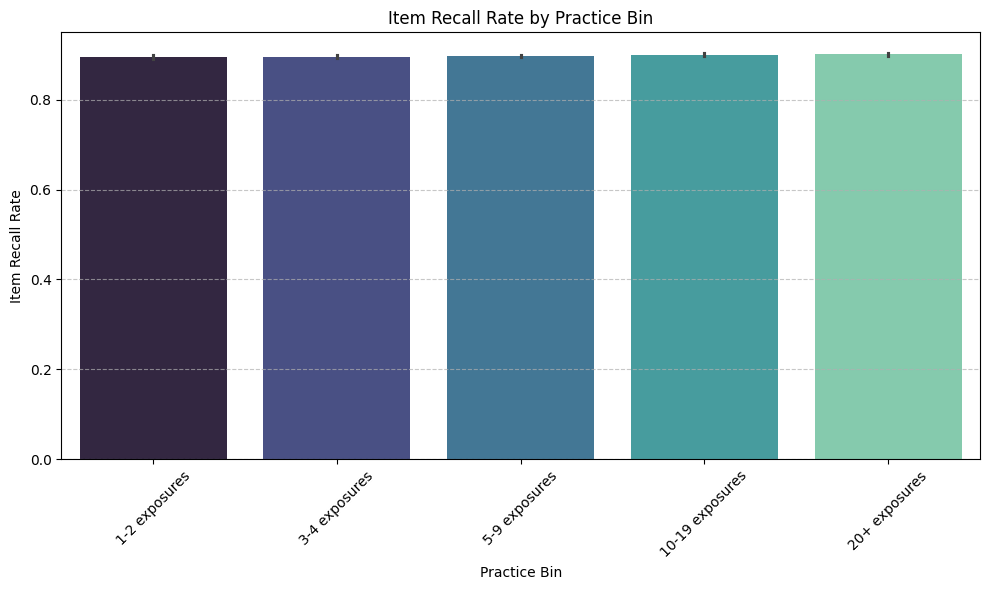

In [ ]:
# Item Recall Rate by Practice Bin
plt.figure(figsize=(10, 6))
sns.barplot(x='practice_bin', y='item_recall_rate', data=df.sort_values('practice_bin_order'), palette='mako')
plt.title('Item Recall Rate by Practice Bin')
plt.xlabel('Practice Bin')
plt.ylabel('Item Recall Rate')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

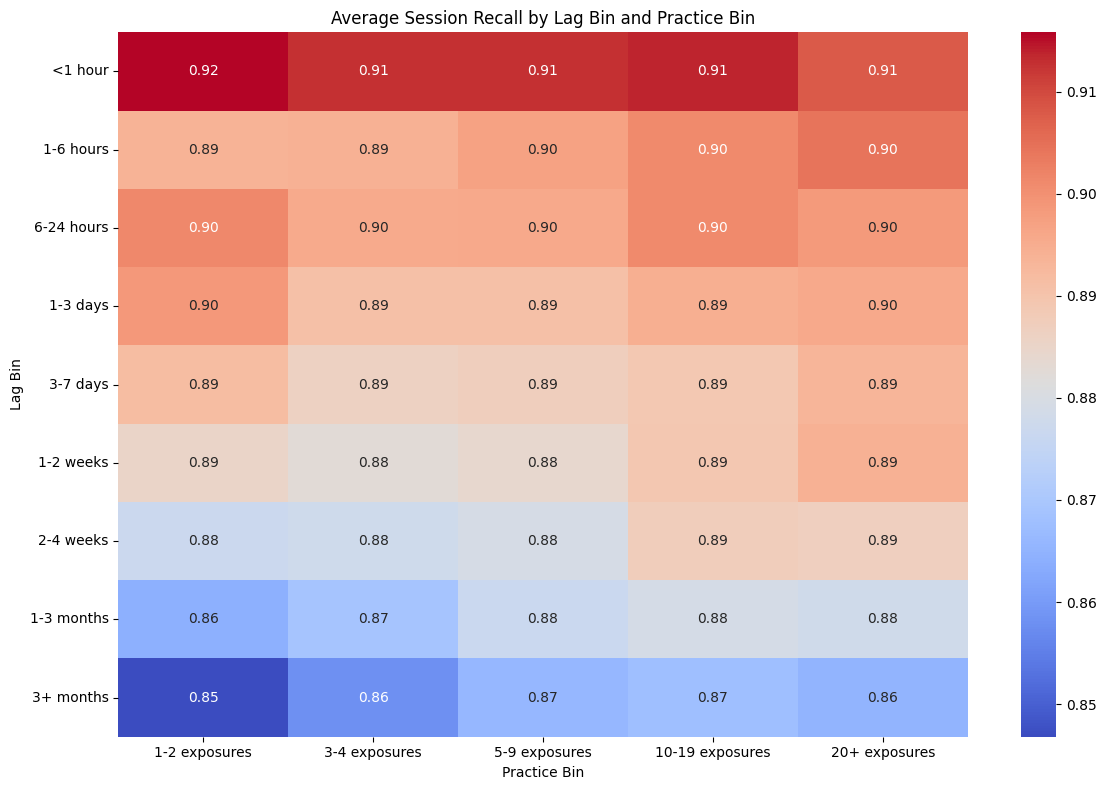

In [ ]:
# Heatmap of Average Session Recall by Lag Bin and Practice Bin
pivot_table = df.pivot_table(index='lag_bin_order', columns='practice_bin_order', values='avg_session_recall')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt=".2f",
            xticklabels=df.sort_values('practice_bin_order')['practice_bin'].unique(),
            yticklabels=df.sort_values('lag_bin_order')['lag_bin'].unique())
plt.title('Average Session Recall by Lag Bin and Practice Bin')
plt.xlabel('Practice Bin')
plt.ylabel('Lag Bin')
plt.tight_layout()
plt.show()

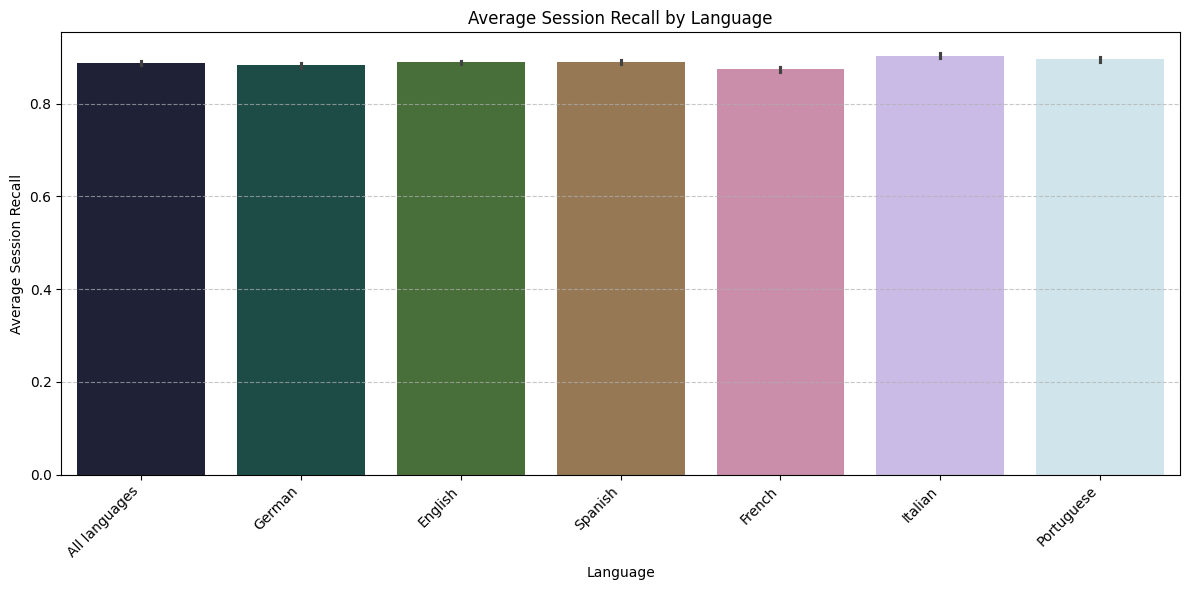

In [ ]:
# Average Session Recall by Language
plt.figure(figsize=(12, 6))
sns.barplot(x='language_name', y='avg_session_recall', data=df, palette='cubehelix')
plt.title('Average Session Recall by Language')
plt.xlabel('Language')
plt.ylabel('Average Session Recall')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

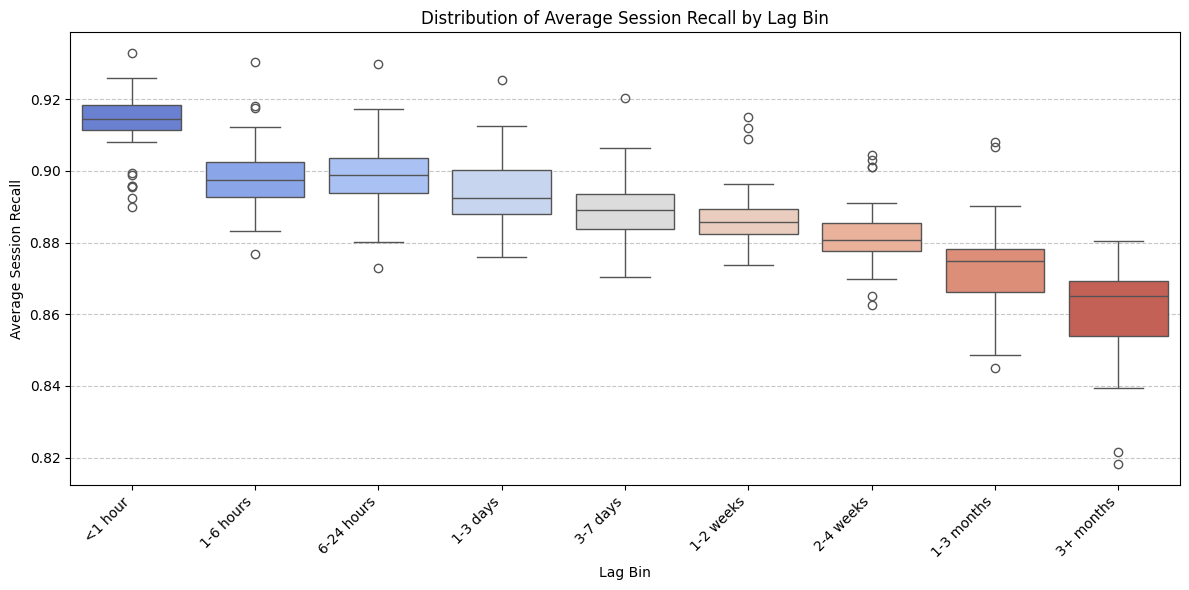

In [ ]:
# Box Plot of Average Session Recall by Lag Bin
plt.figure(figsize=(12, 6))
sns.boxplot(x='lag_bin', y='avg_session_recall', data=df.sort_values('lag_bin_order'), palette='coolwarm')
plt.title('Distribution of Average Session Recall by Lag Bin')
plt.xlabel('Lag Bin')
plt.ylabel('Average Session Recall')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

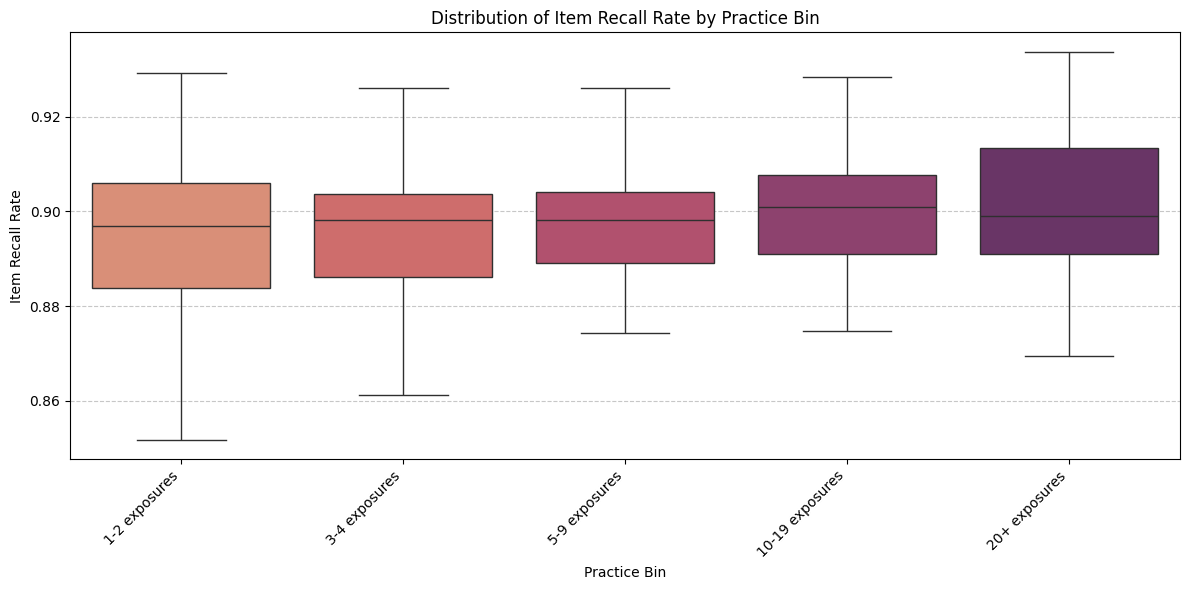

In [ ]:
# Box Plot of Item Recall Rate by Practice Bin
plt.figure(figsize=(12, 6))
sns.boxplot(x='practice_bin', y='item_recall_rate', data=df.sort_values('practice_bin_order'), palette='flare')
plt.title('Distribution of Item Recall Rate by Practice Bin')
plt.xlabel('Practice Bin')
plt.ylabel('Item Recall Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

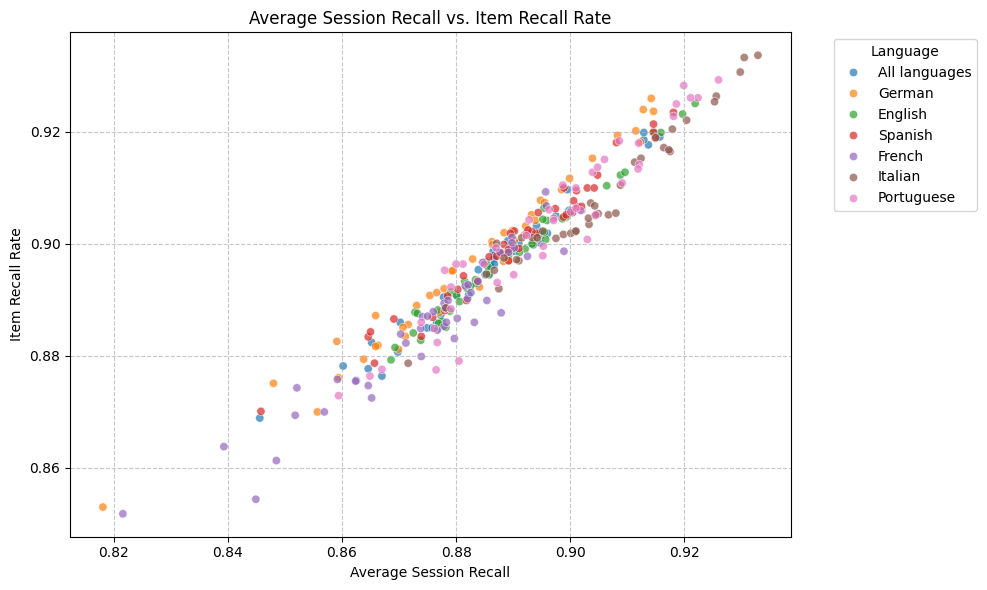

In [ ]:
# Scatter Plot: Average Session Recall vs. Item Recall Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avg_session_recall', y='item_recall_rate', hue='language_name', data=df, alpha=0.7)
plt.title('Average Session Recall vs. Item Recall Rate')
plt.xlabel('Average Session Recall')
plt.ylabel('Item Recall Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Machine Learning: Predicting Recall

In [ ]:
# One-hot encode 'language_name'
df_encoded = pd.get_dummies(df, columns=['language_name'], drop_first=True)

# Display the first few rows of the encoded DataFrame to see the new columns
display(df_encoded.head())

,learning_language,lag_bin,lag_bin_order,practice_bin,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions,language_name_English,language_name_French,language_name_German,language_name_Italian,language_name_Portuguese,language_name_Spanish
0,all,<1 hour,0,1-2 exposures,0,383261,0.9157,0.9191,87.37,False,False,False,False,False,False
1,all,<1 hour,0,3-4 exposures,1,893452,0.9137,0.9177,86.26,False,False,False,False,False,False
2,all,<1 hour,0,5-9 exposures,2,1429269,0.9129,0.9186,86.50,False,False,False,False,False,False
3,all,<1 hour,0,10-19 exposures,3,1023779,0.9129,0.9199,86.00,False,False,False,False,False,False
4,all,<1 hour,0,20+ exposures,4,1239541,0.8995,0.9097,84.58,False,False,False,False,False,False


In [ ]:
# Define features (X) and target (y)
features = ['lag_bin_order', 'practice_bin_order', 'n_traces'] + \
           [col for col in df_encoded.columns if col.startswith('language_name_')]
X = df_encoded[features]
y = df_encoded['avg_session_recall']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (310, 9)
Target (y) shape: (310,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (248, 9)
X_test shape: (62, 9)
y_train shape: (248,)
y_test shape: (62,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.0046
R-squared (R2): 0.8589


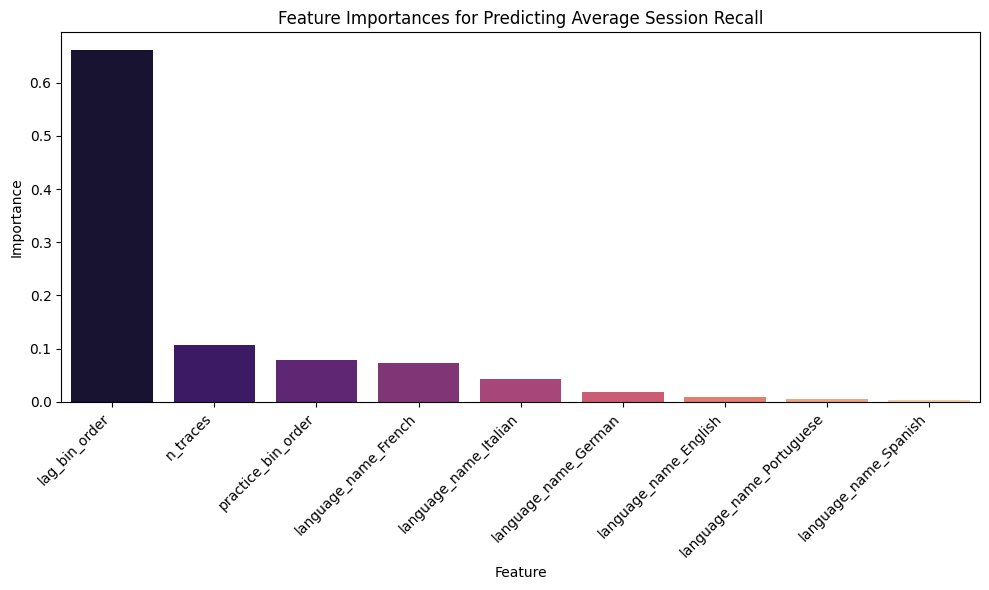

In [ ]:
# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort and plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.sort_values(ascending=False).index,
            y=feature_importances.sort_values(ascending=False).values,
            palette='magma')
plt.title('Feature Importances for Predicting Average Session Recall')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()